<a href="https://colab.research.google.com/github/Cypheraj12/laptop_price-analysis-and-prediction/blob/main/G10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#IMPORTING LIBRARIES

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#LOADING DATASET

In [ ]:
Raw_Data = pd.read_csv("dataset.csv")

#DATSET STRUCTURE ANALYSIS

In [ ]:
Raw_Data.shape

(1303, 12)

In [ ]:
Raw_Data.head()

,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,0.0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,1.0,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232
2,2.0,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000
3,3.0,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360
4,4.0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080


In [ ]:
Raw_Data.tail()

,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
1298,1298.0,Lenovo,2 in 1 Convertible,14,IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i7 6500U 2.5GHz,4GB,128GB SSD,Intel HD Graphics 520,Windows 10,1.8kg,33992.64
1299,1299.0,Lenovo,2 in 1 Convertible,13.3,IPS Panel Quad HD+ / Touchscreen 3200x1800,Intel Core i7 6500U 2.5GHz,16GB,512GB SSD,Intel HD Graphics 520,Windows 10,1.3kg,79866.72
1300,1300.0,Lenovo,Notebook,14,1366x768,Intel Celeron Dual Core N3050 1.6GHz,2GB,64GB Flash Storage,Intel HD Graphics,Windows 10,1.5kg,12201.12
1301,1301.0,HP,Notebook,15.6,1366x768,Intel Core i7 6500U 2.5GHz,6GB,1TB HDD,AMD Radeon R5 M330,Windows 10,2.19kg,40705.92
1302,1302.0,Asus,Notebook,15.6,1366x768,Intel Celeron Dual Core N3050 1.6GHz,4GB,500GB HDD,Intel HD Graphics,Windows 10,2.2kg,19660.32


In [ ]:
Raw_Data.describe()

,Unnamed: 0,Price
count,1273.000000,1273.000000
mean,652.674784,59955.814073
std,376.493027,37332.251005
min,0.000000,9270.720000
25%,327.000000,31914.720000
50%,652.000000,52161.120000
75%,980.000000,79333.387200
max,1302.000000,324954.720000


In [ ]:
Raw_Data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        1273 non-null   float64
 1   Company           1273 non-null   object 
 2   TypeName          1273 non-null   object 
 3   Inches            1273 non-null   object 
 4   ScreenResolution  1273 non-null   object 
 5   Cpu               1273 non-null   object 
 6   Ram               1273 non-null   object 
 7   Memory            1273 non-null   object 
 8   Gpu               1273 non-null   object 
 9   OpSys             1273 non-null   object 
 10  Weight            1273 non-null   object 
 11  Price             1273 non-null   float64
dtypes: float64(2), object(10)
memory usage: 122.3+ KB


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

#**CHECKING FOR NULL VALUES**

In [ ]:
Raw_Data.isnull().sum()

,0
Unnamed: 0,30
Company,30
TypeName,30
Inches,30
ScreenResolution,30
Cpu,30
Ram,30
Memory,30
Gpu,30
OpSys,30


#**VISUALISING NULL VALUES USING HEATMAP**

<Axes: >

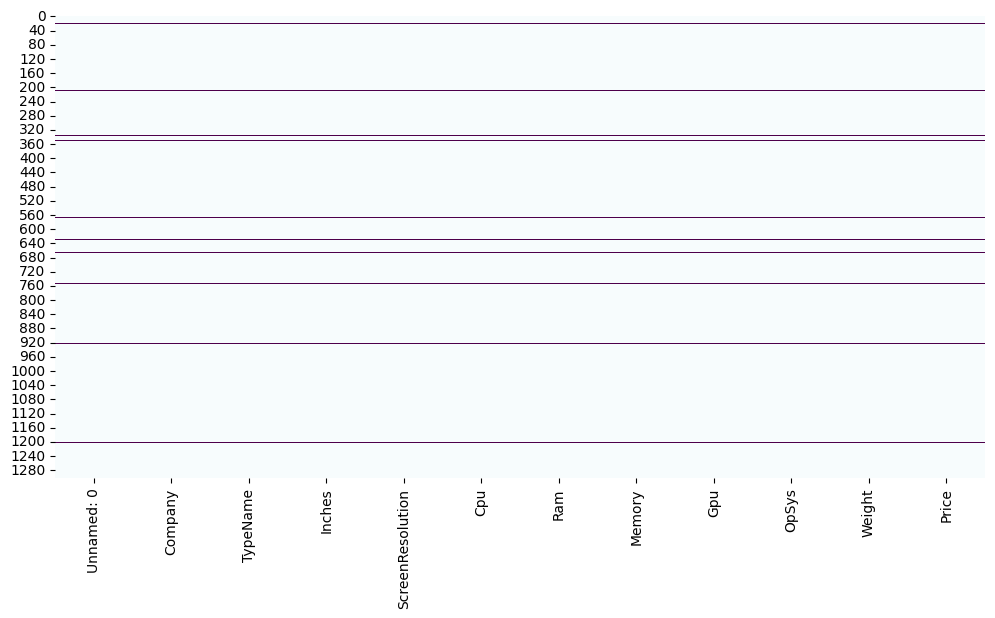

In [ ]:
plt.figure(figsize=(12,6))
sns.heatmap(Raw_Data.isnull(),cbar=False,cmap="BuPu")

#**REMOVING NULL VALUES AND CONVERTING DTYPES TO NUMERIC**

In [ ]:
Clean_Data = Raw_Data.dropna(how='all')
Final_Data = Clean_Data.drop(columns=["Unnamed: 0"])


In [ ]:
# Convert 'Inches' to numeric (float),
#coercing errors - If there are entries that cannot be converted (like missing or malformed text), they are converted into NaN (Not a Number).

Raw_Data['Inches'] = pd.to_numeric(Raw_Data['Inches'], errors='coerce')


# Convert 'Ram' to numeric (int) by removing 'GB', filling missing values first
#regex=False ensures that 'GB' is treated as a literal string.

Raw_Data['Ram'] = Raw_Data['Ram'].astype(str).str.replace('GB','', regex=False)

Raw_Data['Ram'] = pd.to_numeric(Raw_Data['Ram'], errors='coerce')


#Fills the missing values (NaN) in the Ram column with the calculated median.
#After filling, it converts all values to integer format because RAM is always a whole number (like 4, 8, 16 GB).

median_ram = Raw_Data['Ram'].median()

Raw_Data['Ram'] = Raw_Data['Ram'].fillna(median_ram).astype(int)


# Convert 'Weight' to numeric (float) by removing 'kg'

Raw_Data['Weight'] = Raw_Data['Weight'].astype(str).str.replace('kg','', regex=False)
Raw_Data['Weight'] = pd.to_numeric(Raw_Data['Weight'], errors='coerce')

#**REMOVING DUPLICATES VALUES**

In [ ]:
Final_Data.duplicated().sum()    #Removing dupe Data

np.int64(29)

In [ ]:
Final_Data.drop_duplicates(inplace=True)

In [ ]:
Final_Data.duplicated().sum()  #Checking for dupe data again

np.int64(0)

#removing

In [ ]:
# Find rows where any column contains '?'
invalid_rows = Final_Data.isin(['?']).any(axis=1)

# Display rows with invalid entries
print("Rows with invalid entries ('?'):")
print(Final_Data[invalid_rows])


Rows with invalid entries ('?'):
    Company     TypeName Inches   ScreenResolution  \
208    Dell    Ultrabook   13.3  Full HD 1920x1080   
476    Dell  Workstation      ?  Full HD 1920x1080   
770    Dell     Notebook   15.6  Full HD 1920x1080   

                             Cpu   Ram     Memory                     Gpu  \
208   Intel Core i7 8550U 1.8GHz   8GB  256GB SSD  Intel UHD Graphics 620   
476  Intel Core i7 7700HQ 2.8GHz   8GB  256GB SSD     Nvidia Quadro M1200   
770   Intel Core i7 7500U 2.7GHz  16GB          ?      AMD Radeon R7 M445   

          OpSys  Weight        Price  
208  Windows 10       ?   77202.7200  
476  Windows 10  1.78kg  128298.2400  
770  Windows 10   2.3kg   62938.0656  


In [ ]:
# Remove rows with '?' in any column
Final_Data = Final_Data[~invalid_rows]

print("Invalid rows removed. Dataset cleaned.")


Invalid rows removed. Dataset cleaned.


#**UNIVARIATE ANALYSIS**

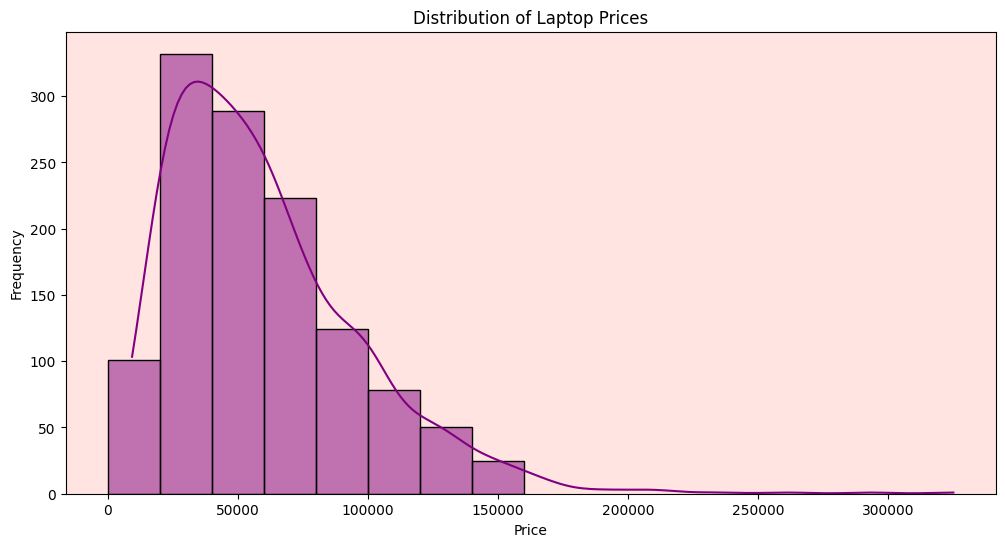

In [ ]:
#@title DISTRIBUTION OF PRICES

your_bins = [0, 20000, 40000, 60000, 80000, 100000, 120000, 140000, 160000]



plt.figure(figsize=(12,6))
ax = plt.subplot()
ax.set_facecolor('mistyrose')
sns.histplot(Final_Data['Price'], kde=True, bins=your_bins,color='purple')
plt.title('Distribution of Laptop Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()



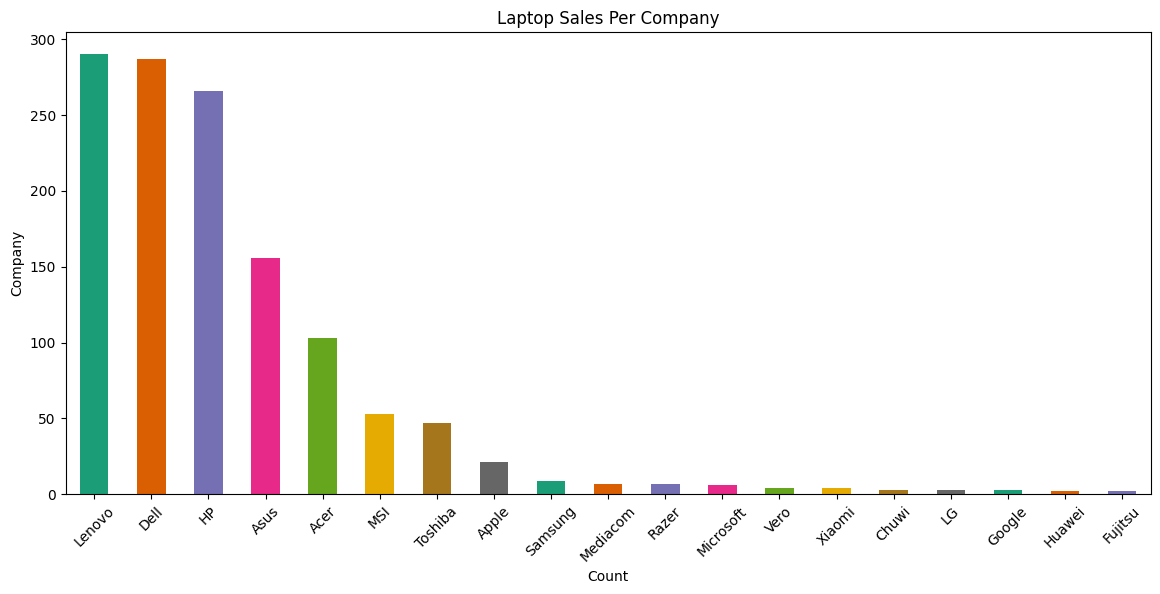

In [ ]:
#@title LAPTOP SALES PER COMPANY

type_counts = Raw_Data['Company'].value_counts()
plt.figure(figsize=(14, 6))
type_counts.plot(kind='bar', color=sns.color_palette('Dark2'))
plt.xlabel('Count')
plt.ylabel('Company')
plt.title('Laptop Sales Per Company')
plt.xticks(rotation=45)
plt.show()

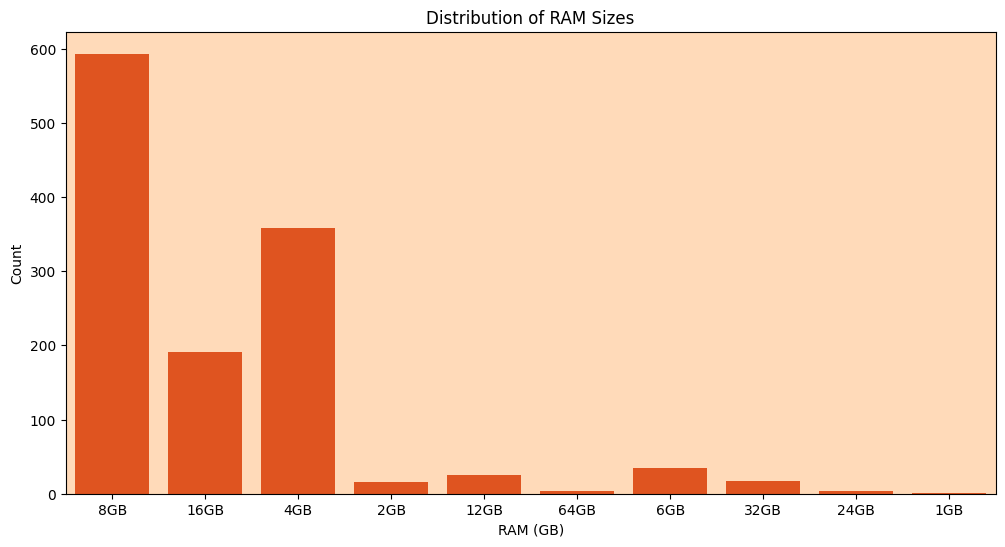

In [ ]:
#@title DISTRIBUTION OF RAM

plt.figure(figsize=(12,6))
ax = plt.subplot()
ax.set_facecolor('peachpuff')
sns.countplot(x=Final_Data['Ram'],color='orangered')
plt.title('Distribution of RAM Sizes')
plt.xlabel('RAM (GB)')
plt.ylabel('Count')
plt.show()


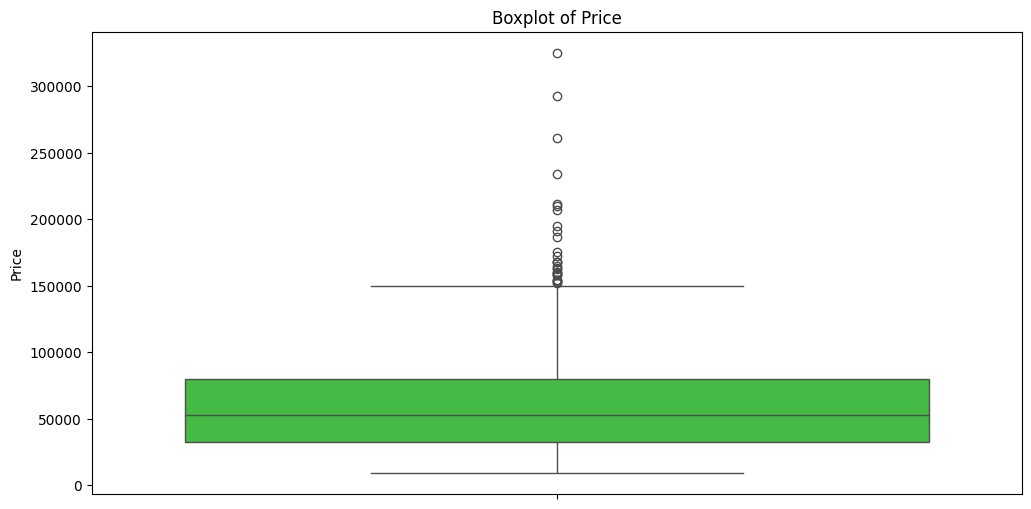

In [ ]:
plt.figure(figsize = (12,6))
sns.boxplot(data=Final_Data["Price"], color='limegreen')
plt.title("Boxplot of Price")
plt.show()

#**REMOVING OUTLIERS**

In [ ]:
Q1 = Final_Data["Price"].quantile(0.25)
Q3 = Final_Data["Price"].quantile(0.75)
IQR = Q3 - Q1
print(IQR)

47173.57920000001


In [ ]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print(lower_bound)
print(upper_bound)

-38120.508000000016
150573.8088


In [ ]:
End_Data = Final_Data[~((Final_Data["Price"] < lower_bound) | (Final_Data["Price"] > upper_bound))] # it only stores false value because we used ~

# **Feature Enginnering**

In [ ]:
End_Data['Has_Dedicated_GPU'] = ~End_Data['Gpu'].str.contains('Intel', case=False)
#Tells if the laptop has dedicated Gpu

/tmp/ipython-input-1428352207.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  End_Data['Has_Dedicated_GPU'] = ~End_Data['Gpu'].str.contains('Intel', case=False)


In [ ]:
# Step 1: Convert 'Weight' from string (like '1.37kg') to float
End_Data['Weight'] = End_Data['Weight'].astype(str).str.replace('kg','', regex=False)
End_Data['Weight'] = pd.to_numeric(End_Data['Weight'], errors='coerce')
median_w = End_Data['Weight'].median()

End_Data['Weight'] = End_Data['Weight'].fillna(median_w).astype(float)

# Convert 'Ram' to numeric (int) by removing 'GB'
End_Data["Ram"] = End_Data['Ram'].astype(str).str.replace('GB', '', regex=False).astype(int)
ram_num = End_Data['Ram'].astype(str).str.replace('GB', '', regex=False).astype(int)

median_ram = End_Data['Ram'].median()

End_Data['Ram'] = End_Data['Ram'].fillna(median_ram).astype(int)


# Extract CPU GHz
cpu_ghz = End_Data['Cpu'].str.extract(r'(\d\.\d)GHz').fillna(0).astype(float)

# Convert Has_Dedicated_GPU to GPU score
gpu_score = End_Data['Has_Dedicated_GPU'].apply(lambda x: 2 if x else 1)

# Calculate raw performance score
performance_raw = ram_num + cpu_ghz.iloc[:, 0] * 2 + gpu_score * 3

# Normalize to max 10
max_raw = performance_raw.max()
End_Data['Performance_Score'] = ((performance_raw / max_raw) * 10).round(2)

/tmp/ipython-input-1757516634.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  End_Data['Weight'] = End_Data['Weight'].astype(str).str.replace('kg','', regex=False)
/tmp/ipython-input-1757516634.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  End_Data['Weight'] = pd.to_numeric(End_Data['Weight'], errors='coerce')
/tmp/ipython-input-1757516634.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See t

In [ ]:
def price_category(price):
    if price < 30000:
        return 'Budget'
    elif price < 70000:
        return 'Mid-Range'
    else:
        return 'Premium'

End_Data['Price_Category'] = End_Data['Price'].apply(price_category)


/tmp/ipython-input-88727534.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  End_Data['Price_Category'] = End_Data['Price'].apply(price_category)


In [ ]:
End_Data.head()

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Has_Dedicated_GPU,Performance_Score,Price_Category
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,False,2.12,Premium
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,False,1.98,Mid-Range
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,False,2.17,Mid-Range
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,True,3.72,Premium
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,False,2.34,Premium


#**BIVARIATE ANALYSIS**


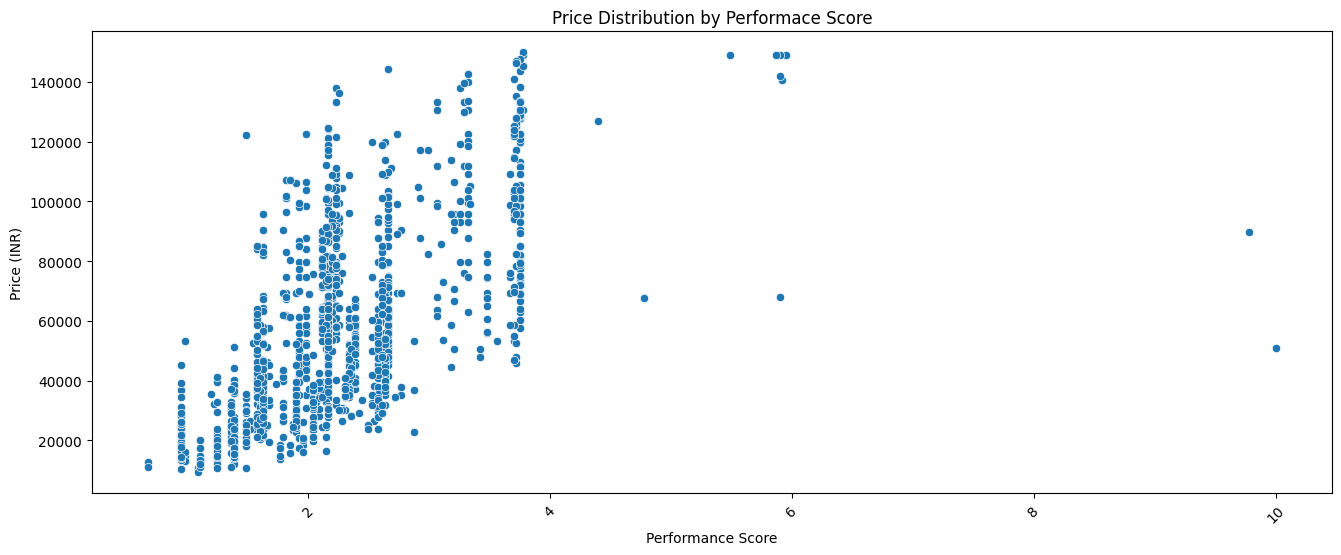

In [ ]:
#@title price vs company

plt.figure(figsize=(16,6))
sns.scatterplot(x='Performance_Score', y='Price', data=End_Data)
plt.title('Price Distribution by Performace Score')
plt.xlabel('Performance Score')
plt.ylabel('Price (INR)')
plt.xticks(rotation=45)
plt.show()


Text(0.5, 1.0, 'Correlation Heatmap')

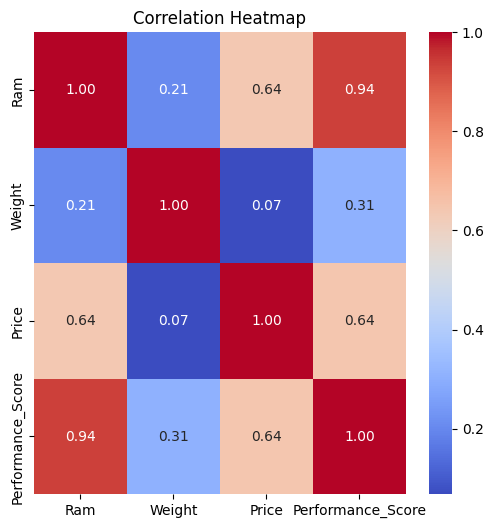

In [ ]:
corr = End_Data.select_dtypes(include=[np.number]).corr() # only take numaric values
plt.figure(figsize=(6,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt= ".2f")
plt.title('Correlation Heatmap')

# **Model**

In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
encoder=LabelEncoder()

In [ ]:
cloumns_to_encode=["Has_Dedicated_GPU"]

In [ ]:
End_Data[cloumns_to_encode] = End_Data[cloumns_to_encode].apply(encoder.fit_transform)
End_Data["Price_Category"] = encoder.fit_transform(End_Data["Price_Category"])

/tmp/ipython-input-4289258999.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  End_Data[cloumns_to_encode] = End_Data[cloumns_to_encode].apply(encoder.fit_transform)
/tmp/ipython-input-4289258999.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  End_Data["Price_Category"] = encoder.fit_transform(End_Data["Price_Category"])


In [ ]:
comp  = pd.get_dummies(End_Data,columns=["Company", "Ram","TypeName","Performance_Score","Inches"])

In [ ]:
X = comp.drop(["Price","ScreenResolution","Cpu","Memory","Gpu","OpSys","Weight"], axis=1)
Y = comp["Price"]


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.1,random_state=140)

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
model = LinearRegression()

In [ ]:
model.fit(X_train,Y_train)      #training the model

LinearRegression()

In [ ]:
model.predict(X_test)

array([ 24274.93765107,  84532.1341951 ,  18711.93288079, 102612.51203708,
        55109.82900302,  52178.21575188,  47884.89594355,  46128.9845401 ,
        56792.90073787,  46827.60822778,  13439.61122769,  81036.82477574,
        20545.37392664,  26521.94268688,  47711.99011714,  38477.94707219,
        99099.43958017,  80378.4219857 , 100421.65199558,  93472.33919511,
        46589.86790971,  14467.30567731,  49288.40982978,  57984.8641623 ,
       107885.81312926,  99422.70387677,  21550.55262613,  71602.35595914,
        52703.20933608,  96457.24754633,  55418.64643499,  24747.94368002,
        69837.16903897,  50969.46811394,  49190.02183035,  40927.4214864 ,
        44119.89638045,  90538.66494668,  52178.21575188,  50803.08539673,
        20547.87590066,  78479.4344853 ,  14062.98974886,  92175.35853432,
        52869.388597  ,  18967.43042554,  49457.83957914,  47504.11489525,
        49943.54551931,  16821.57530279,  17185.48216793, 108776.03740837,
        50969.46811394,  

In [ ]:
Y_test

,Price
49,24828.48
1028,86526.72
32,23389.92
203,93186.72
697,35644.32
...,...
212,18594.72
557,50562.72
1180,87219.36
816,95850.72


In [ ]:
 # ------------------------
# PREDICTION FUNCTION
# ------------------------
feature_columns = X.columns.tolist()

def predict_price(has_gpu, company, ram, typename, performance_score, inches, price_category):
    # Start with 0s for all feature columns from training
    input_data = pd.DataFrame([[0]*len(feature_columns)], columns=feature_columns)

    # One-hot categorical
    col_ram = f"Ram_{ram}"
    col_typename = f"TypeName_{typename}"
    col_company = f"Company_{company}"

    if col_ram in input_data.columns:
        input_data[col_ram] = 1
    if col_typename in input_data.columns:
        input_data[col_typename] = 1
    if col_company in input_data.columns:
        input_data[col_company] = 1

    # Has_Dedicated_GPU (already label encoded during training)
    if "Has_Dedicated_GPU" in input_data.columns:
        input_data["Has_Dedicated_GPU"] = 1 if has_gpu else 0

    # Performance_Score was one-hot encoded → set correct dummy
    col_perf = f"Performance_Score_{performance_score}"
    if col_perf in input_data.columns:
        input_data[col_perf] = 1

    # Inches was one-hot encoded → set correct dummy
    col_inches = f"Inches_{inches}"
    if col_inches in input_data.columns:
        input_data[col_inches] = 1

    # Price_Category (label encoded during training)
    if "Price_Category" in input_data.columns:
        if price_category == "budget":
            input_data["Price_Category"] = 0
        elif price_category == "mid-range":
            input_data["Price_Category"] = 1
        else:
            input_data["Price_Category"] = 2

    # Predict
    predicted_price = model.predict(input_data)[0]
    return round(predicted_price, 2)

# ------------------------
# USER INPUT (Interactive in Colab - Ordered)
# ------------------------

# 1. Has GPU
has_gpu_input = input("Has dedicated GPU? (yes/no): ").strip().lower()
has_gpu = True if has_gpu_input in ["yes", "y", "1", "true"] else False

# 2. Company
company = input("Enter Company (e.g., Apple, Asus, HP, Lenovo): ").strip().capitalize()

# 3. RAM
ram = int(input("Enter RAM (e.g., 4, 8, 16): ").strip())

# 4. TypeName
typename = input("Enter TypeName (e.g., Notebook, Gaming, Ultrabook): ").strip().capitalize()

# 5. Performance Score Range
print("\nChoose Performance Score Range:")
print("1 → Low (1–3)")
print("2 → Medium (4–6)")
print("3 → High (7–10)")
perf_choice = input("Enter your choice (1/2/3): ").strip()

if perf_choice == "1":
    performance_score = 2.0   # mid of 1–3
elif perf_choice == "2":
    performance_score = 5.0   # mid of 4–6
else:
    performance_score = 8.5   # mid of 7–10

# 6. Inches
inches = float(input("Enter screen size in inches (e.g., 14, 15.6): ").strip())

# 7. Price Category
price_category = input("Enter Price Category (Budget/Mid-Range/Premium): ").strip().lower()

# ------------------------
# PREDICTION
# ------------------------
predicted = predict_price(has_gpu, company, ram, typename, performance_score, inches, price_category)
print(f"\n💻 Predicted Price for your configuration: ₹{predicted}")


Has dedicated GPU? (yes/no): yes
Enter Company (e.g., Apple, Asus, HP, Lenovo): Asus
Enter RAM (e.g., 4, 8, 16): 8
Enter TypeName (e.g., Notebook, Gaming, Ultrabook): Gaming

Choose Performance Score Range:
1 → Low (1–3)
2 → Medium (4–6)
3 → High (7–10)
Enter your choice (1/2/3): 2
Enter screen size in inches (e.g., 14, 15.6): 15.6
Enter Price Category (Budget/Mid-Range/Premium): premium

💻 Predicted Price for your configuration: ₹83636.86
